# The CUSUM Control Chart
### STAT 7110 — Quality Control
**Dr. Austin R. Brown**  
*Kennesaw State University*

---

### Table of Contents
1. [Introduction](#introduction)
2. [Motivation: Where Shewhart Charts Fall Short](#the-cusum-chart--motivation)
3. [The CUSUM Chart](#the-cusum-chart)
4. [The Tabular CUSUM](#the-cusum-chart--tabular-cusum)
5. [Choosing $K$ and $H$](#the-cusum-chart--choosing-k)
6. [Worked Example: Soda Bottles](#the-cusum-chart-in-r)
7. [Chart Design & ARL](#cusum-chart-design)
8. [Beyond the Mean: Other CUSUM Applications](#cusum-chart-usage)
9. [Additional Examples](#cusum--additional-example-n--1-customer-hold-times)
10. [Limitations](#cusum-limitations)


In [6]:
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "Abarre71"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}
## Set working drive to today's lecture:
getwd()
setwd("STAT-7110-Quality-Control//Slides//Week-4-CUSUM")

[1] "Repository already cloned to Colab."


[1] "/content"

## Introduction

Every monitoring system, whether it's a manufacturing line, a server fleet, or a fraud-detection pipeline, eventually runs into the same question: *how small of a change do I actually need to catch, and how fast?* The Shewhart $\bar{X}$ and R/s charts we've used so far answer that question in a specific way, and it turns out that answer has real limits.

| What the Shewhart chart does well | Where it struggles |
|---|---|
| Easy to build and interpret | Not sensitive to **small** shifts in the mean ($\leq 2\sigma$) |
| Great at catching **large** shifts ($>2\sigma$) quickly | Not effective when $n = 1$ (individual measurements) |
| Each point is judged independently — simple to reason about | ...which also means it *wastes* information — it ignores the pattern formed by the whole sequence of points |

That last point is the key insight: since we assume consecutive observations are independent, a chart that only looks at the *most recent* point is throwing away everything the rest of the sequence could tell us about a slow, creeping drift.

What we want is a chart that:

- Uses information from the **entire sequence** of points, not just the latest one
- Works even when $n = 1$
- Is sensitive to **small** shifts in the process mean

This week we'll build the first of two charts designed with exactly that goal in mind: the **Cumulative Summation (CUSUM)** chart. Next week, we'll cover its close cousin, the **Exponentially Weighted Moving Average (EWMA)** chart.

## The CUSUM Chart — Motivation

![Limitation of Shewhart Chart](https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/main/Slides/Week-4-CUSUM/Shewhartlimitation.JPG)

Take a look at the chart above. The first 20 observations come from a normal distribution with mean 10 and standard deviation 1. The next 10 come from a normal distribution with mean 11 and standard deviation 1. Here, we see a real, sustained shift of one standard deviation.

If we were only watching the control limits, **we would miss it entirely.** Every point still falls comfortably inside the limits, even though the process has genuinely moved. This is exactly the blind spot small, gradual shifts create for a Shewhart-style chart. This is the kind of drift you'd see in a slowly degrading sensor, a warehouse process losing efficiency, or a website's conversion rate quietly eroding over a few weeks.

So how does the CUSUM chart catch what the Shewhart chart misses?

## The CUSUM Chart

The CUSUM chart was proposed by [Page (1954)](https://academic.oup.com/biomet/article-abstract/41/1-2/100/456627?redirectedFrom=fulltext), and the core idea is one that shows up all over modern change-point and drift-detection methods — from quality control to monitoring dashboards that watch for anomalies in server latency or transaction volume.

Here's the concept:

- Say we want to monitor the mean of a process, and this process has a target value, $\mu_0$. To monitor the process, we still take random samples and obtain an estimate of the sample mean, $\bar{x}_i$.

- Instead of plotting $\bar{x}_i$ itself, we take the deviance between the target value and the sample mean, $\bar{x}_i - \mu_0$.

## The CUSUM Chart

The "cumulative summation" part of the name comes from the fact that the plotting statistic is a running total of those deviances:

$$ C_i = \sum_{j=1}^{i}(\bar{x}_i - \mu_0) $$

The idea: if the process starts to drift upward or downward, those cumulative differences will *keep growing* and eventually signal that a shift has occurred — even if no single point would ever trip a Shewhart control limit. Notice we're now using **every** $\bar{x}_i$ observed so far, not just the latest one.

There's a catch, though. $C_i$'s distribution is *non-stationary*. If you've taken a time series course, you'll recognize that as meaning the mean and/or variance changes over time. If we assume $\bar{x}_i$ is normally distributed with mean $\mu_0$ and variance $\sigma^2/n$, then:

$$ C_i = \sum_{j=1}^{i}(\bar{x}_i - \mu_0) \;\dot\sim\; N\bigg(0, \frac{i\sigma^2}{n}\bigg) $$

Notice the variance grows with $i$. That's a real problem if we want to construct control limits in a Shewhart-style manner. The limits would need to keep widening over time and would never settle down to a steady value.

There are two standard fixes for this, but we'll focus on the one used almost universally in practice: the **Tabular CUSUM**.

## The CUSUM Chart — Tabular CUSUM

Instead of one running sum, the Tabular CUSUM tracks **two** statistics side by side: an upper CUSUM that accumulates evidence of an upward shift, and a lower CUSUM that accumulates evidence of a downward shift:

$$ C^{+}_i = \max\big[0,\; \bar{x}_i - (\mu_0 + K) + C_{i-1}^{+}\big] $$
$$ C^{-}_i = \max\big[0,\; (\mu_0 - K) - \bar{x}_i + C_{i-1}^{-}\big] $$

where $C^+_{0} = C^{-}_{0} = 0$ and $K$ is referred to as the "slack" or "allowance" value. The `max(0, ...)` is what keeps each statistic from drifting off into negative territory when the process is behaving. It resets to zero rather than accumulating "credit" that could mask a future shift.

## The CUSUM Chart — Choosing $K$

$K$ is typically chosen to be the midpoint between our target value, $\mu_0$, and an out-of-control value, $\mu_1$, that we're specifically interested in catching quickly:

$$ K = \frac{|\mu_1 - \mu_0|}{2} $$

| Statistic | Detects |
|---|---|
| $C^{+}$ | Upward shifts ($\mu_1 > \mu_0$) |
| $C^{-}$ | Downward shifts ($\mu_1 < \mu_0$) |

If either $C^{+}_i$ or $C^{-}_i$ exceeds some control limit, $H$, that's our signal the process may be out of control (OOC).

## The CUSUM Chart — Choosing $H$

What about $H$? Typically, it's chosen as a multiple of the process standard deviation, $\sigma$.

**Rule of thumb:** set $H = h\sigma$, where $h = 4$ or $5$.

## The CUSUM Chart in R

Time to put this into practice. Suppose we're filling soda bottles on a production line, with a target fill of $\mu_0 = 16$ oz, and we pull a sample of 5 bottles every hour for two days (48 hours).

We'll use $K = 0.5$ and $H = 5$.

In [13]:
## Load the Libraries ##
install.packages(c("tidyverse", "readxl", "qcc"))
library(tidyverse)
library(readxl)
library(qcc)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



### Read in the Soda Bottles data

In [14]:
bottles <- read_xlsx("Soda Bottles.xlsx")

bottles |>
  glimpse()

Rows: 48
Columns: 5
$ `Bottle 1` <dbl> 15.78, 16.35, 16.03, 16.08, 16.10, 16.14, 16.09, 16.13, 16.…
$ `Bottle 2` <dbl> 16.14, 16.05, 16.19, 16.31, 16.55, 16.22, 16.13, 16.18, 16.…
$ `Bottle 3` <dbl> 15.94, 15.80, 16.08, 15.96, 16.06, 15.98, 15.92, 16.44, 16.…
$ `Bottle 4` <dbl> 16.19, 16.12, 16.38, 16.13, 16.23, 16.24, 16.42, 16.32, 16.…
$ `Bottle 5` <dbl> 16.53, 16.03, 16.29, 16.28, 16.26, 15.76, 16.40, 16.20, 16.…


### Calculate sample means & overall SD

In [15]:
bottles_means <- rowMeans(bottles)
sigma_hat <- sd.xbar(bottles,std.dev="UWAVE-SD")

mu0 <- 16

### Standardize the row means

In [16]:
z_means <- (bottles_means - mu0)/(sigma_hat/sqrt(5))

### Calculate the CUSUM values manually before using the `qcc` function

In [17]:
k <- 0.5
h <- 5

CUSUM_df <- tibble(Means = z_means)

## Calculate C+ and C- values prior to taking maximums ##

CUSUM_df <- CUSUM_df |>
  mutate(C_plus = Means-k,
         C_minus = -k-Means)

### Create a loop to accumulate $C^+$ and $C^-$

In [18]:
c_plus <- vector('double',length=nrow(CUSUM_df))
c_minus <- vector('double',length=nrow(CUSUM_df))

for(i in 1:length(c_plus)){

  if(i==1){

    c_plus[i] <- max(0,CUSUM_df$C_plus[i])
    c_minus[i] <- max(0,CUSUM_df$C_minus[i])

  } else {

    c_plus[i] <- max(0,CUSUM_df$C_plus[i] + c_plus[i-1])
    c_minus[i] <- max(0,CUSUM_df$C_minus[i] + c_minus[i-1])

  }

}

### Plot the manually-calculated CUSUM chart

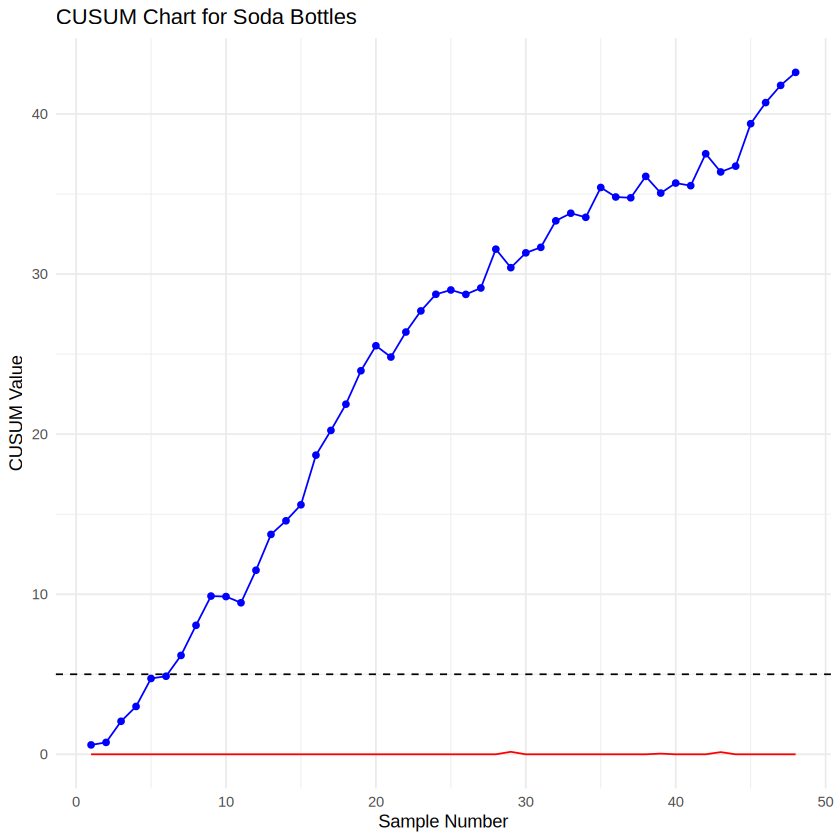

In [19]:
CUSUM_df <- CUSUM_df |>
  mutate(C_plus1 = c_plus,
         C_minus1 = c_minus)

CUSUM_df |>
  ggplot(aes(x=1:nrow(CUSUM_df))) +
  geom_line(aes(y=C_plus1),color="blue") +
  geom_point(aes(y=C_plus1),color='blue') +
  geom_line(aes(y=C_minus1),color="red") +
  geom_hline(yintercept=h,linetype="dashed") +
  labs(title="CUSUM Chart for Soda Bottles",
       x="Sample Number",
       y="CUSUM Value") +
  theme_minimal()

### Now how do we do this using the `qcc` package?

Note: `qcc` wants to standardize the data, so we need to be mindful of this.

List of 14
 $ call             : language cusum(data = bottles, sizes = 5, center = mu0, decision.interval = h, se.shift = k *      2, plot = T)
 $ type             : chr "cusum"
 $ data.name        : chr "bottles"
 $ data             : num [1:48, 1:5] 15.8 16.4 16 16.1 16.1 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:48] 16.1 16.1 16.2 16.2 16.2 ...
  ..- attr(*, "names")= chr [1:48] "1" "2" "3" "4" ...
 $ sizes            : num [1:48] 5 5 5 5 5 5 5 5 5 5 ...
 $ center           : num 16
 $ std.dev          : num 0.237
 $ pos              : num [1:48] 0.594 0.754 2.084 3.018 4.781 ...
 $ neg              : num [1:48] 0 0 0 0 0 0 0 0 0 0 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

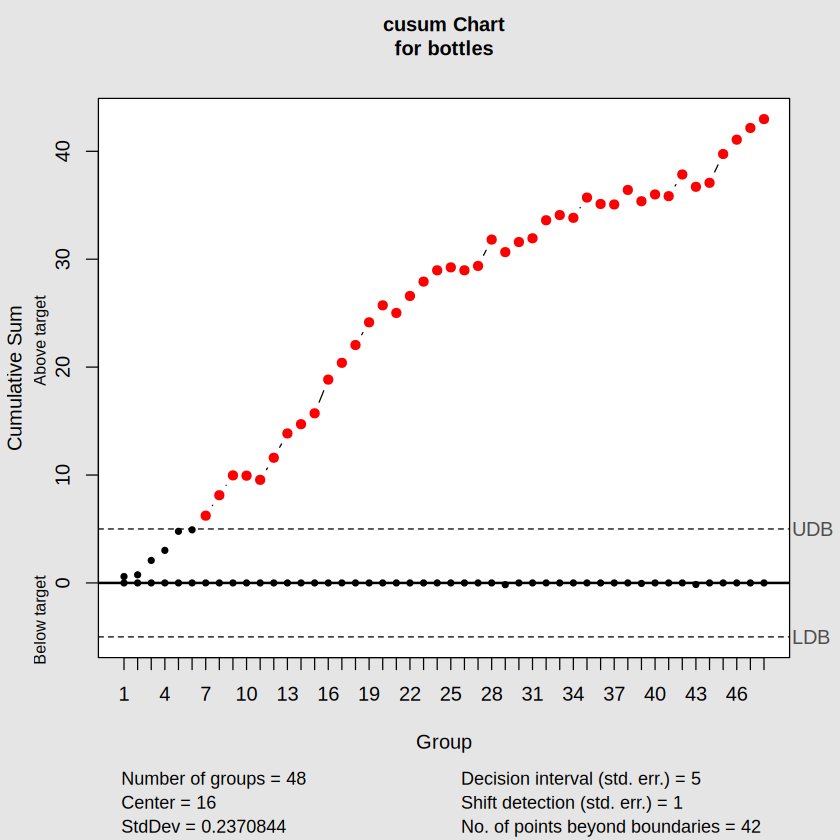

In [20]:
cusum(bottles,sizes=5,center=mu0,se.shift=k*2,
      decision.interval = h,plot=T)

This lets us know that the process is **not** in control for $\mu_0 = 16$, as the upper CUSUM values exceed the decision interval.

## CUSUM Chart Design

In the last example we just used $H=5$ and $K=0.50$ without much explanation — so where do those numbers actually come from?

Generally, the rule of thumb is $H = h\sigma$ and $K = k\sigma$, where $h = 4$ or $5$ and $k = 0.50$. Given a known or estimated value of $\sigma$, that's enough to obtain $H$ and $K$ directly.

*Note: in our example, we standardized the sample means using the estimated standard deviation, which is why we could just use $H=5$ and $K=0.50$ directly — no extra scaling needed.*

## CUSUM Chart Design — ARL Curve

![CUSUM ARL Curve]((https://raw.githubusercontent.com/abrown9008/STAT-7110-Quality-Control/main/Slides/Week-4-CUSUM/CUSUM_ARL.JPG))

## CUSUM Chart Usage

So far we've only used CUSUM to monitor sample means when $n \geq 1$. However, the same logic generalizes well beyond that:

- **Sample standard deviations** — catching a process that's becoming less consistent, not just off-target
- **Sample proportions and defect counts** — the same idea behind monitoring a defect rate, a website error rate, or a churn rate over time
- **Variable sample sizes** — by standardizing observations, exactly like we did in the soda bottles example

The common thread: anywhere you have a sequence of standardized deviations from a target, CUSUM logic applies.

## CUSUM ARL Estimation

- Unlike the Shewhart-style charts, the plotting statistics for the CUSUM chart are not independent of each other. Thus, the typical $ARL_0 = 1/\alpha$ and $ARL_1 = 1/(1-\beta)$ calculations aren't valid.

- Estimating ARL for CUSUM charts can be quite complicated. However, we do have some rough estimates that we can use in Phase I when making decisions about chart construction.

- For a one-sided CUSUM, Siegmund (1985) provided an approximation:

$$ ARL = \frac{\exp(-2\Delta b) + 2\Delta b - 1}{2\Delta^2} $$

- where $\Delta = \delta^* - k$ for the upper CUSUM, $\Delta = -\delta^* - k$ for the lower CUSUM, $b = h + 1.166$, and $\delta^* = (\mu_1 - \mu_0)/\sigma$.

- Then, if we're using a two-sided CUSUM, we can estimate the overall ARL by:

$$ \frac{1}{ARL} = \frac{1}{ARL^{+}} + \frac{1}{ARL^{-}} $$

In general, the ARL for a CUSUM with $k=0.5$ and $h=5$ is:

| Shift in Mean | $ARL$ |
|:---:|:---:|
| 0 | 465 |
| 0.25 | 139 |
| 0.50 | 38 |
| 0.75 | 17 |
| 1.00 | 10.4 |
| 2.00 | 4.01 |
| 3.00 | 2.57 |


## CUSUM — Additional Example: $n = 1$ (Customer Hold Times)

CUSUM also works when we have individual observations ($n=1$), not just sample means. Let's monitor the amount of time customers spend on hold at a customer service support center, where the target hold time is $\mu_0 = 10$ minutes and $\sigma = 1$ minute.

In [21]:
customer_hold <- read_xlsx("EWMA Datasets.xlsx",sheet=1)

customer_hold |>
  glimpse()

Rows: 30
Columns: 2
$ Call <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19…
$ Time <dbl> 9.45, 7.99, 9.29, 11.66, 12.16, 10.18, 8.04, 11.46, 9.20, 10.34, …


List of 14
 $ call             : language cusum(data = customer_hold$Time, sizes = 1, center = 10, decision.interval = 5,      se.shift = k * 2, plot = T, sigma = 1)
 $ type             : chr "cusum"
 $ data.name        : chr "customer_hold$Time"
 $ data             : num [1:30, 1] 9.45 7.99 9.29 11.66 12.16 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:30] 9.45 7.99 9.29 11.66 12.16 ...
  ..- attr(*, "names")= chr [1:30] "1" "2" "3" "4" ...
 $ sizes            : num [1:30] 1 1 1 1 1 1 1 1 1 1 ...
 $ center           : num 10
 $ std.dev          : num 1.2
 $ pos              : num [1:30] 0 0 0 0.883 2.184 ...
 $ neg              : num [1:30] 0 -1.18 -1.27 0 0 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

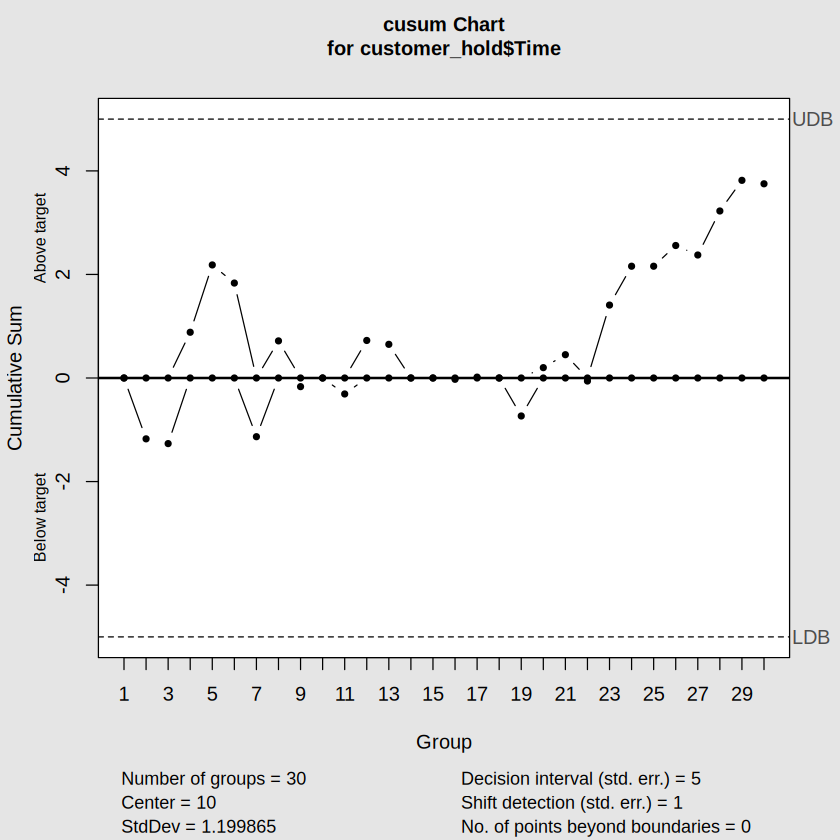

In [22]:
cusum(customer_hold$Time,sizes=1,center=10,sigma=1,
      se.shift=k*2,decision.interval = 5,plot=T)

## CUSUM — Additional Example: Fuel Costs

Suppose we're the Scranton branch of Dunder-Mifflin. In order for our branch to be profitable, we need to maximize sales and control our operating costs. One such operating cost is the amount of fuel our warehouse delivery trucks use. In the second sheet of this week's class data, we have the past 24 months of fuel costs. Here we don't know the process mean and standard deviation, so we'll estimate them and check whether the process is in control.

In [23]:
fuel_costs <- read_xlsx("EWMA Datasets.xlsx",sheet=2)

fuel_costs |>
  glimpse()

Rows: 24
Columns: 2
$ Cost  <dbl> 5525.27, 5084.35, 4021.17, 4923.73, 5254.42, 5404.45, 4843.34, 5…
$ month <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9…


### Estimate the process mean and standard deviation

In [24]:
## Estimate process mean ##

mu0 <- mean(fuel_costs$Cost)

## Estimate process standard deviation ##

sigma_hat <- sd(fuel_costs$Cost)

List of 14
 $ call             : language cusum(data = fuel_costs$Cost, sizes = 1, center = mu0, decision.interval = 5,      se.shift = k * 2, plot = T, si| __truncated__
 $ type             : chr "cusum"
 $ data.name        : chr "fuel_costs$Cost"
 $ data             : num [1:24, 1] 5525 5084 4021 4924 5254 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:24] 5525 5084 4021 4924 5254 ...
  ..- attr(*, "names")= chr [1:24] "1" "2" "3" "4" ...
 $ sizes            : num [1:24] 1 1 1 1 1 1 1 1 1 1 ...
 $ center           : num 5001
 $ std.dev          : num 395
 $ pos              : num [1:24] 0.828 0.54 0 0 0.143 ...
 $ neg              : num [1:24] 0 0 -1.981 -1.675 -0.533 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

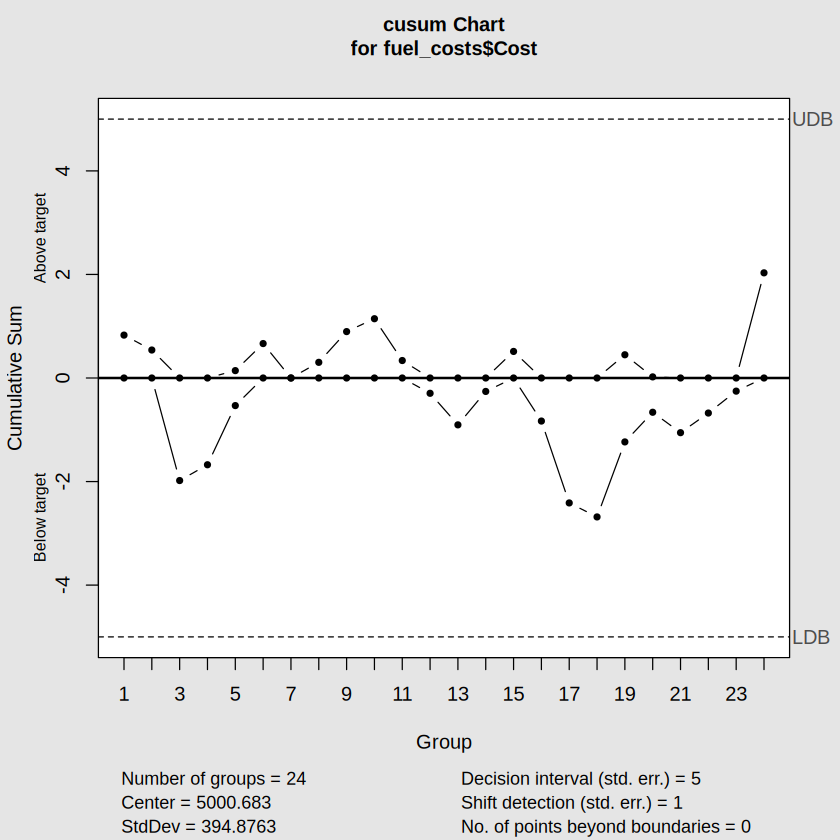

In [25]:
cusum(fuel_costs$Cost,sizes=1,center=mu0,sigma=sigma_hat,
      se.shift=k*2,decision.interval = 5,plot=T)

It appears that the process is in control using the estimated mean and standard deviation.

## CUSUM Limitations

As powerful as it is, the CUSUM chart isn't without tradeoffs:

- Compared to the Shewhart $\bar{X}$ chart, it's **more complex** to implement and interpret — there's no single point you can eyeball against a limit; you have to track the accumulation.
- It's also **less obvious how to set** the control parameters, $H$ and $K$, compared to a Shewhart chart's $3\sigma$ limits.

So the natural question: can we keep CUSUM's sensitivity to small shifts while getting back some of the Shewhart chart's simplicity? That's exactly what the **EWMA chart** offers — see next week's notebook!